In [22]:
import asyncio
import re
import json
from typing import Tuple, List, Dict
import httpx


def extract_apollo_state(html):
    """Extract apollo graphql state data from HTML source"""
    print("test=",html)
    match = re.findall(r'apolloState":\s*({.+})};', html)
    if not match:
        raise ValueError("apolloState não encontrado na página")
    data = json.loads(match[0])
    data = json.loads(data)
    return data


def parse_reviews(html) -> Tuple[List[Dict], int]:
    """parse jobs page for job data and total amount of jobs"""
    cache = extract_apollo_state(html)
    xhr_cache = cache["ROOT_QUERY"]
    reviews = next(v for k, v in xhr_cache.items() if k.startswith("employerReviews") and v.get("reviews"))
    return reviews


async def scrape_reviews(employer: str, employer_id: str, session: httpx.AsyncClient):
    """Scrape job listings"""
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0 Safari/537.36",
        "Accept-Language": "en-US,en;q=0.9",
    }
    # scrape first page of jobs:
    first_page = await session.get(
        url=f"https://www.glassdoor.fr/Avis/{employer}-Avis-E{employer_id}.htm?countryRedirect=true",
        headers=headers
    )
    print("test2 =", first_page.text)
    reviews = parse_reviews(first_page.text)
    # find total amount of pages and scrape remaining pages concurrently
    total_pages = reviews["numberOfPages"]
    print(f"scraped first page of reviews, scraping remaining {total_pages - 1} pages")
    other_pages = [
        session.get(
            url=str(first_page.url).replace(".htm", f"_P{page}.htm"),
        )
        for page in range(2, total_pages + 1)
    ]
    for page in await asyncio.gather(*other_pages):
        page_reviews = parse_reviews(page.text)
        reviews["reviews"].extend(page_reviews["reviews"])
    return reviews



test2 = <!DOCTYPE html>
<html>
	<head>
		<title>Security | Glassdoor</title>
		<meta http-equiv="content-type" content="text/html;charset=utf-8" />
		<meta name='viewport' content='width=device-width, initial-scale=1'/>
		<meta name="theme-color" content="#0caa41">
		<style type="text/css">body,html{background:#fff;font-family:Helvetica Neue,HelveticaNeue,Helvetica,Arial,sans-serif;font-size:16px;margin:0;padding:0}div,h1,h2,h3,h4,h5,h6,p{color:#20262e}.header{-webkit-box-shadow:inset 0 -1px 0 0 #dee0e3;box-shadow:inset 0 -1px 0 0 #dee0e3}.header .center{height:45px}.header .center:before{content:"";height:100%;margin-right:-.25em}.header .center:before,.logo{display:inline-block;vertical-align:middle}.center{margin:0 auto;width:996px}.article,.center{box-sizing:border-box}.article{background-color:#fff;border-radius:3px;box-shadow:0 0 2px #c4c7cc;height:100%;margin:16px 0;max-width:690px;padding:16px}h1{font-size:20px;font-weight:900;line-height:1em;margin-top:0}h2{font-size:18px;font
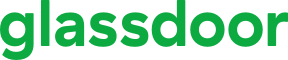
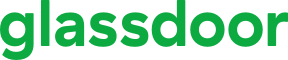

ValueError: apolloState não encontrado na página

In [23]:
async def main():
    async with httpx.AsyncClient(
        timeout=httpx.Timeout(30.0),
        cookies={"tldp": "1"},
        follow_redirects=True,
    ) as client:
        reviews = await scrape_reviews("eBay", "7853", client)
        print(json.dumps(reviews, indent=2))

await main()

#asyncio.run(main())

<html dir="ltr"><head>
<title>Um momento…</title>
<meta content="text/html;charset=utf-8" http-equiv="content-type"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<meta content="#0caa41" name="theme-color"/>
<style type="text/css">body,html{background:#fff;font-family:Helvetica Neue,HelveticaNeue,Helvetica,Arial,sans-serif;font-size:16px;margin:0;padding:0}div,h1,h2,h3,h4,h5,h6,p{color:#20262e}.header{-webkit-box-shadow:inset 0 -1px 0 0 #dee0e3;box-shadow:inset 0 -1px 0 0 #dee0e3}.header .center{height:45px}.header .center:before{content:"";height:100%;margin-right:-.25em}.header .center:before,.logo{display:inline-block;vertical-align:middle}.center{margin:0 auto;width:996px}.article,.center{box-sizing:border-box}.article{background-color:#fff;border-radius:3px;box-shadow:0 0 2px #c4c7cc;height:100%;margin:16px 0;max-width:690px;padding:16px}h1{font-size:20px;font-weight:900;line-height:1em;margin-top:0}h2{font-size:18px;font-weight:400;margin:16px 0}@media on
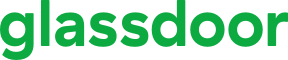

In [34]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import time

options = Options()
options.add_argument('--headless')  # se não quiser abrir a janela do navegador
options.add_argument('--disable-blink-features=AutomationControlled')  # menos detectável

driver = webdriver.Chrome(options=options)
url = 'https://www.glassdoor.fr/Avis/eBay-France-Avis-EI_IE7853.0,4_IL.5,11_IN86.htm?filter.iso3Language=fra&filter.employmentStatus=REGULAR&filter.employmentStatus=PART_TIME'

driver.get(url)
time.sleep(5)  # dá tempo para a página carregar e o JS rodar

html = driver.page_source
soup = BeautifulSoup(html, 'html.parser')
print(soup)
driver.quit()

print(soup.prettify()[:1000])  # printa só os primeiros 1000 caracteres para conferir


In [35]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

options = Options()
options.add_argument('--headless')  # modo invisível
options.add_argument('--disable-gpu')

driver = webdriver.Chrome(options=options)
driver.get("https://www.google.com")
print(driver.title)
driver.quit()

Google


<!DOCTYPE html>

<html>
<head>
<title>Security | Glassdoor</title>
<meta content="text/html;charset=utf-8" http-equiv="content-type"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<meta content="#0caa41" name="theme-color"/>
<style type="text/css">body,html{background:#fff;font-family:Helvetica Neue,HelveticaNeue,Helvetica,Arial,sans-serif;font-size:16px;margin:0;padding:0}div,h1,h2,h3,h4,h5,h6,p{color:#20262e}.header{-webkit-box-shadow:inset 0 -1px 0 0 #dee0e3;box-shadow:inset 0 -1px 0 0 #dee0e3}.header .center{height:45px}.header .center:before{content:"";height:100%;margin-right:-.25em}.header .center:before,.logo{display:inline-block;vertical-align:middle}.center{margin:0 auto;width:996px}.article,.center{box-sizing:border-box}.article{background-color:#fff;border-radius:3px;box-shadow:0 0 2px #c4c7cc;height:100%;margin:16px 0;max-width:690px;padding:16px}h1{font-size:20px;font-weight:900;line-height:1em;margin-top:0}h2{font-size:18px;font-weight:400;margin
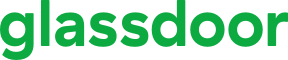

In [ ]:
from requests_html import HTMLSession
import lxml_html_clean
from bs4 import BeautifulSoup

s = HTMLSession()
url = 'https://www.glassdoor.fr/Avis/eBay-France-Avis-EI_IE7853.0,4_IL.5,11_IN86.htm?filter.iso3Language=fra&filter.employmentStatus=REGULAR&filter.employmentStatus=PART_TIME'

def getdata(url):
    r = s.get(url)
    soup = BeautifulSoup(r.text, 'html.parser')
    return soup


print(getdata(url))